# Rasterize

`xrspatial.rasterize` converts vector geometries (polygons, lines, points) into a 2D `xr.DataArray` using scanline fill, Bresenham line drawing, and direct pixel burn. It works from a GeoDataFrame or a list of `(geometry, value)` pairs, with no GDAL dependency.

**Backends:** NumPy, CuPy, Dask+NumPy, Dask+CuPy.

Any existing DataArray (or Dataset) can serve as a grid template via the `.xrs.rasterize()` accessor, which passes the array's coordinates as the `like` parameter automatically.

This notebook walks through:
1. Basic rasterization with the `.xrs` accessor
2. Overlapping polygons and holes
3. Lines and points
4. Merge modes (how overlapping features combine)
5. Custom merge functions with numba
6. Multi-column feature properties
7. Dask parallel rasterization
8. Practical use case: zonal statistics
9. Using `all_touched`
10. List-of-pairs input (standalone function)

In [1]:
import numpy as np
import xarray as xr
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import box, Polygon, Point, LineString, MultiPoint

import xrspatial  # registers .xrs accessor
from xrspatial.rasterize import rasterize
from xrspatial.utils import ngjit

## 1. Basic rasterization with the `.xrs` accessor

Create a template DataArray that defines the output grid, then call `.xrs.rasterize()` on it. The accessor reads width, height, bounds, and dtype from the template's coordinates.

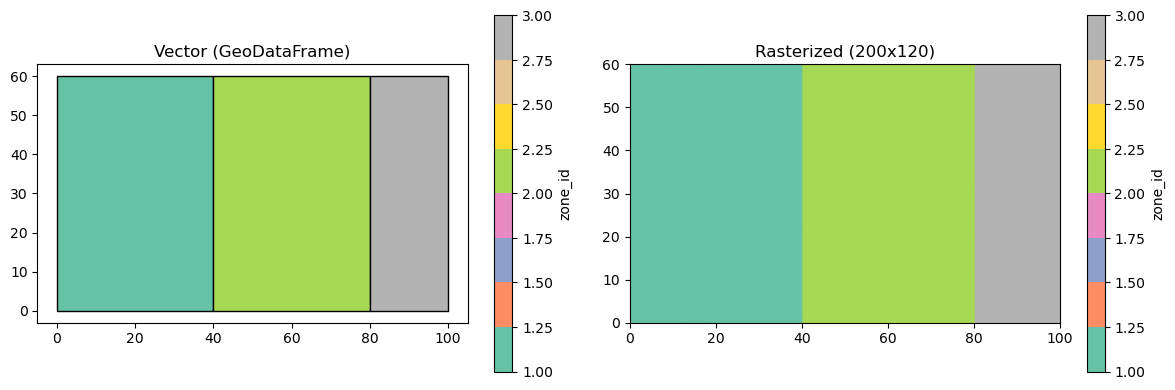

In [2]:
# Helper to build a template DataArray from grid parameters
def make_template(width, height, bounds, dtype=np.float64):
    xmin, ymin, xmax, ymax = bounds
    px = (xmax - xmin) / width
    py = (ymax - ymin) / height
    x = np.linspace(xmin + px / 2, xmax - px / 2, width)
    y = np.linspace(ymax - py / 2, ymin + py / 2, height)
    return xr.DataArray(np.zeros((height, width), dtype=dtype),
                        dims=['y', 'x'], coords={'y': y, 'x': x})

# Three non-overlapping land-use zones
gdf = gpd.GeoDataFrame({
    'zone_id': [1.0, 2.0, 3.0],
    'label': ['forest', 'urban', 'water'],
}, geometry=[
    box(0, 0, 40, 60),    # forest on the left
    box(40, 0, 80, 60),   # urban in the middle
    box(80, 0, 100, 60),  # water on the right
])

template = make_template(200, 120, (0, 0, 100, 60))
raster = template.xrs.rasterize(gdf, column='zone_id', fill=0)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Vector view
gdf.plot(ax=axes[0], column='zone_id', cmap='Set2', edgecolor='black',
         legend=True, legend_kwds={'label': 'zone_id'})
axes[0].set_title('Vector (GeoDataFrame)')

# Raster view
im = axes[1].imshow(raster.values, cmap='Set2', origin='upper',
                    extent=[0, 100, 0, 60])
axes[1].set_title('Rasterized (200x120)')
plt.colorbar(im, ax=axes[1], label='zone_id')
plt.tight_layout()
plt.show()

## 2. Overlapping polygons

When polygons overlap, the last polygon in the GeoDataFrame wins by default (last-writer-wins). See section 4 for other merge modes.

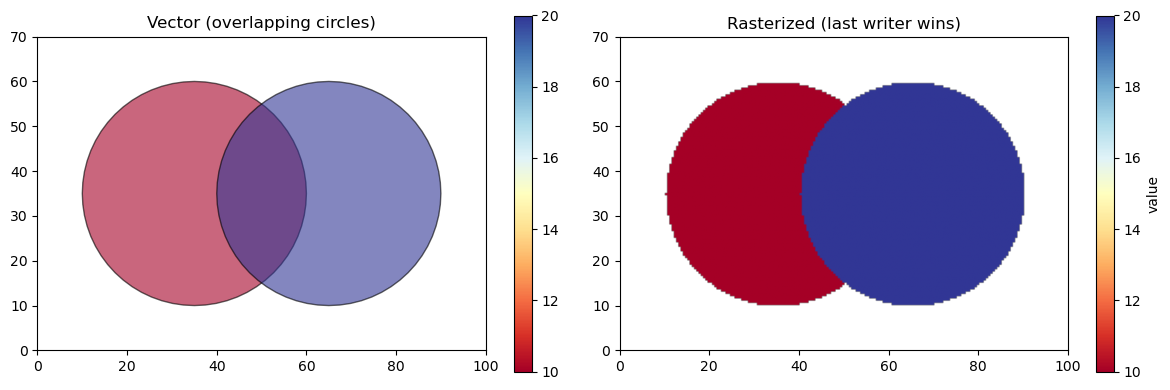

In [3]:
# Two overlapping circles (approximated as polygons)
circle_a = Point(35, 35).buffer(25)
circle_b = Point(65, 35).buffer(25)

gdf_overlap = gpd.GeoDataFrame(
    {'value': [10.0, 20.0]},
    geometry=[circle_a, circle_b],
)

template_70 = make_template(200, 140, (0, 0, 100, 70))
raster_overlap = template_70.xrs.rasterize(gdf_overlap, column='value')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
gdf_overlap.plot(ax=axes[0], column='value', cmap='RdYlBu', alpha=0.6,
                 edgecolor='black', legend=True)
axes[0].set_title('Vector (overlapping circles)')
axes[0].set_xlim(0, 100)
axes[0].set_ylim(0, 70)

im = axes[1].imshow(raster_overlap.values, cmap='RdYlBu', origin='upper',
                    extent=[0, 100, 0, 70])
axes[1].set_title('Rasterized (last writer wins)')
plt.colorbar(im, ax=axes[1], label='value')
plt.tight_layout()
plt.show()

Interior rings (holes) are handled correctly -- pixels inside the hole remain unfilled.

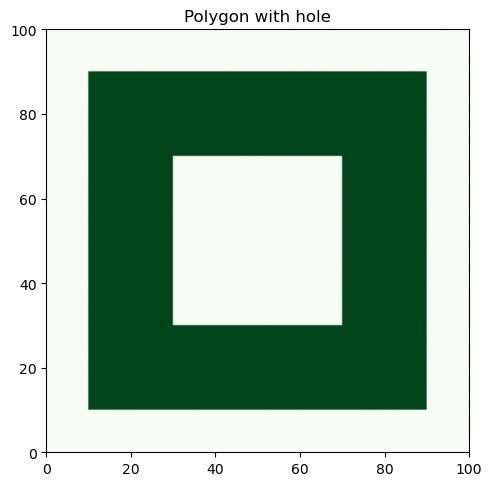

In [4]:
# Polygon with a rectangular hole
exterior = [(10, 10), (90, 10), (90, 90), (10, 90), (10, 10)]
hole = [(30, 30), (30, 70), (70, 70), (70, 30), (30, 30)]
poly_with_hole = Polygon(exterior, [hole])

template_100 = make_template(200, 200, (0, 0, 100, 100))
raster_hole = template_100.xrs.rasterize([(poly_with_hole, 1.0)], fill=0)

fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(raster_hole.values, cmap='Greens', origin='upper',
          extent=[0, 100, 0, 100])
ax.set_title('Polygon with hole')
plt.tight_layout()
plt.show()

## 3. Lines and points

`rasterize` handles LineString, MultiLineString, Point, and MultiPoint geometries alongside polygons. Lines are drawn with Bresenham's algorithm; points burn single pixels.

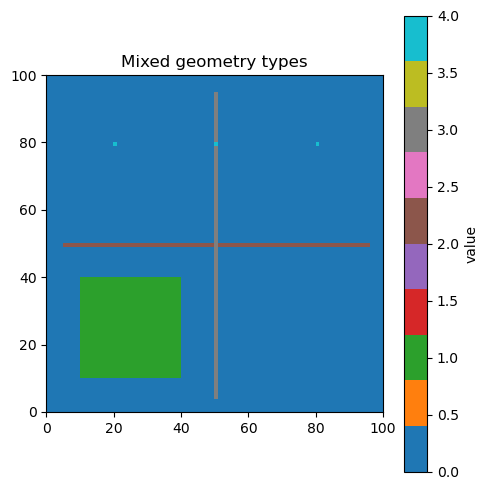

In [5]:
mixed_features = [
    (box(10, 10, 40, 40), 1.0),                              # polygon
    (LineString([(5, 50), (95, 50)]), 2.0),                   # horizontal line
    (LineString([(50, 5), (50, 95)]), 3.0),                   # vertical line
    (MultiPoint([(20, 80), (50, 80), (80, 80)]), 4.0),       # three points
]

small = make_template(100, 100, (0, 0, 100, 100))
mixed = small.xrs.rasterize(mixed_features, fill=0)

fig, ax = plt.subplots(figsize=(5, 5))
im = ax.imshow(mixed.values, cmap='tab10', origin='upper',
               extent=[0, 100, 0, 100], interpolation='nearest')
ax.set_title('Mixed geometry types')
plt.colorbar(im, ax=ax, label='value')
plt.tight_layout()
plt.show()

## 4. Merge modes

When multiple geometries cover the same pixel, the `merge` parameter controls how values combine.  Built-in modes: `'last'` (default), `'first'`, `'max'`, `'min'`, `'sum'`, `'count'`.

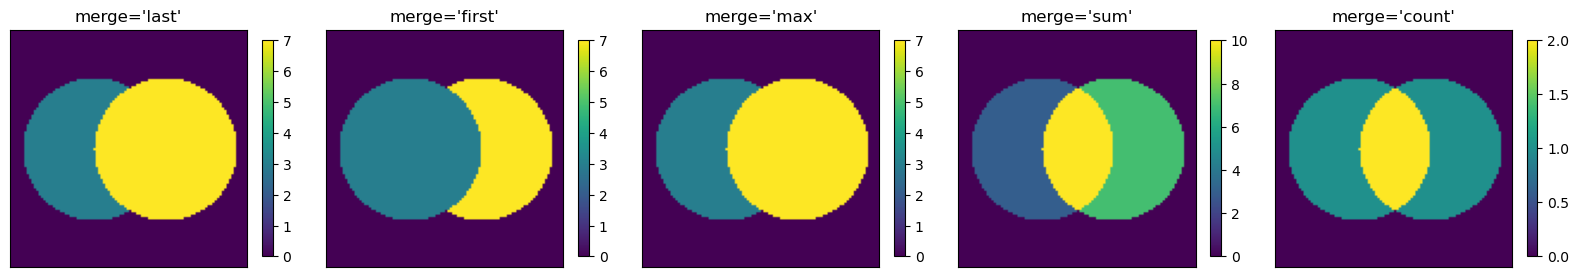

In [6]:
# Two overlapping circles with different values
circle_a = Point(35, 50).buffer(30)
circle_b = Point(65, 50).buffer(30)
pairs = [(circle_a, 3.0), (circle_b, 7.0)]

modes = ['last', 'first', 'max', 'sum', 'count']
fig, axes = plt.subplots(1, len(modes), figsize=(16, 3))

for ax, mode in zip(axes, modes):
    r = small.xrs.rasterize(pairs, fill=0, merge=mode)
    im = ax.imshow(r.values, cmap='viridis', origin='upper',
                   extent=[0, 100, 0, 100])
    ax.set_title(f"merge='{mode}'")
    ax.set_xticks([])
    ax.set_yticks([])
    plt.colorbar(im, ax=ax, shrink=0.8)

plt.tight_layout()
plt.show()

## 5. Custom merge functions

Instead of a string, you can pass a numba-jitted function as `merge`. The function receives three arguments:

- `pixel` -- current pixel value (the `fill` value on first write)
- `props` -- 1D float64 array of feature properties
- `is_first` -- 1 on first write to this pixel, 0 otherwise

It returns the new pixel value. For single-column inputs (the `column` parameter or `(geom, value)` pairs), `props` has length 1 and `props[0]` is the feature's value.

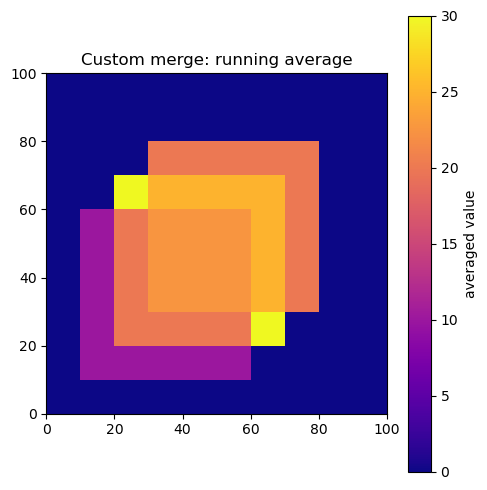

In [7]:
# Running average: each overlapping feature nudges the pixel toward its value
@ngjit
def running_avg(pixel, props, is_first):
    if is_first:
        return props[0]
    return (pixel + props[0]) / 2.0

# Stack three overlapping squares with values 10, 20, 30
avg_pairs = [
    (box(10, 10, 60, 60), 10.0),
    (box(30, 30, 80, 80), 20.0),
    (box(20, 20, 70, 70), 30.0),
]

result_avg = small.xrs.rasterize(avg_pairs, fill=0, merge=running_avg)

fig, ax = plt.subplots(figsize=(5, 5))
im = ax.imshow(result_avg.values, cmap='plasma', origin='upper',
               extent=[0, 100, 0, 100])
ax.set_title('Custom merge: running average')
plt.colorbar(im, ax=ax, label='averaged value')
plt.tight_layout()
plt.show()

## 6. Multi-column feature properties

When working with a GeoDataFrame, you can pass `columns=['col_a', 'col_b', ...]` to make multiple columns available as `props[0]`, `props[1]`, etc. inside your custom merge function. This is useful for computations that depend on more than one attribute per feature.

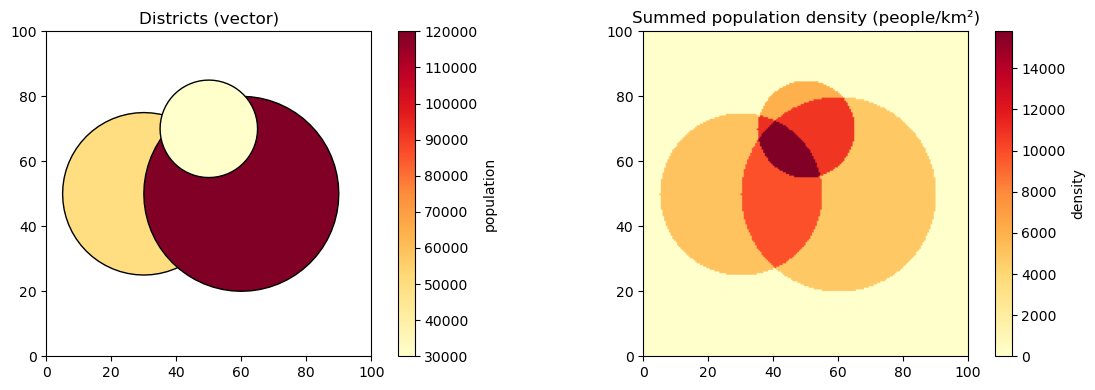

In [8]:
# Population density: population / area, summed where districts overlap
@ngjit
def sum_density(pixel, props, is_first):
    # props[0] = population, props[1] = area_km2
    density = props[0] / props[1]
    if is_first:
        return density
    return pixel + density

districts = gpd.GeoDataFrame({
    'population': [50000.0, 120000.0, 30000.0],
    'area_km2':   [10.0,    25.0,     5.0],
}, geometry=[
    Point(30, 50).buffer(25),
    Point(60, 50).buffer(30),
    Point(50, 70).buffer(15),
])

density_raster = template_100.xrs.rasterize(
    districts, columns=['population', 'area_km2'],
    merge=sum_density, fill=0,
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
districts.plot(ax=axes[0], column='population', cmap='YlOrRd',
               edgecolor='black', legend=True,
               legend_kwds={'label': 'population'})
axes[0].set_title('Districts (vector)')
axes[0].set_xlim(0, 100); axes[0].set_ylim(0, 100)

im = axes[1].imshow(density_raster.values, cmap='YlOrRd', origin='upper',
                    extent=[0, 100, 0, 100])
axes[1].set_title('Summed population density (people/km²)')
plt.colorbar(im, ax=axes[1], label='density')
plt.tight_layout()
plt.show()

## 7. Dask parallel rasterization

Pass `chunks=(row_size, col_size)` to split the output raster into tiles and rasterize them in parallel via `dask.delayed`. The result is a lazy dask-backed DataArray -- call `.compute()` to materialize it.

This works with all merge modes (built-in and custom) and with `use_cuda=True` for GPU tiles.

Type:   <class 'dask.array.core.Array'>
Chunks: ((70, 70), (100, 100))
Shape:  (140, 200)

Dask output matches eager numpy output exactly.


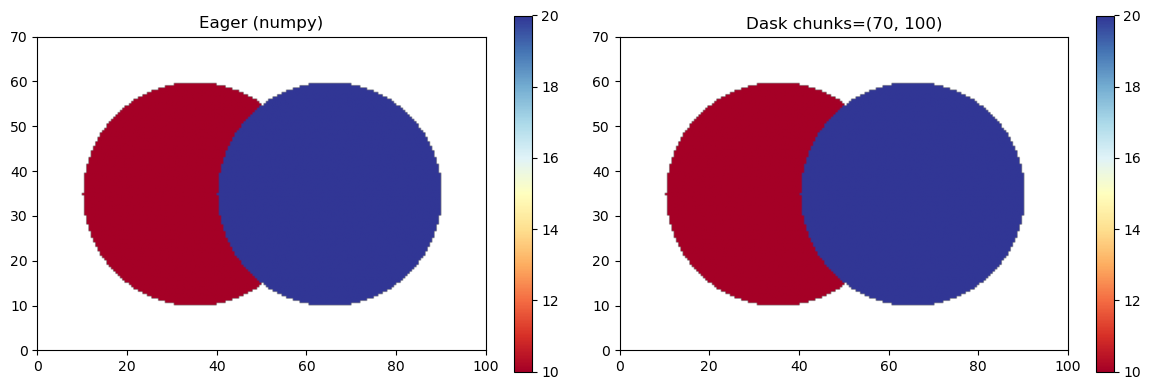

In [9]:
import dask.array as da

# Reuse the overlapping-circles GeoDataFrame from section 2
dask_result = template_70.xrs.rasterize(
    gdf_overlap, column='value', chunks=(70, 100))

print(f"Type:   {type(dask_result.data)}")
print(f"Chunks: {dask_result.data.chunks}")
print(f"Shape:  {dask_result.shape}")

# Compare against eager result from section 2
computed = dask_result.compute()
np.testing.assert_array_equal(computed.values, raster_overlap.values)
print("\nDask output matches eager numpy output exactly.")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
im0 = axes[0].imshow(raster_overlap.values, cmap='RdYlBu', origin='upper',
                     extent=[0, 100, 0, 70])
axes[0].set_title('Eager (numpy)')
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(computed.values, cmap='RdYlBu', origin='upper',
                     extent=[0, 100, 0, 70])
axes[1].set_title('Dask chunks=(70, 100)')
plt.colorbar(im1, ax=axes[1])
plt.tight_layout()
plt.show()

## 8. Practical use case: rasterize zones, then compute zonal statistics

Here the accessor shines: rasterize zone polygons onto the same grid as an existing elevation raster, so coordinates match automatically.

Zonal statistics (elevation by zone):
   zone        mean         max         min         sum        std  \
0     1  199.071472  454.432190  -32.990555  1990714.75  87.410072   
1     2  349.874268  581.182556  102.518471  3498742.75  87.093697   
2     3  450.369202  677.957336  218.092270  4503692.00  86.928917   
3     4  601.038147  850.860046  370.118195  6010381.50  86.688675   

           var    count    majority  
0  7640.520996  10000.0  374.972137  
1  7585.312012  10000.0  337.710327  
2  7556.636719  10000.0  385.624481  
3  7514.925781  10000.0  527.156006  


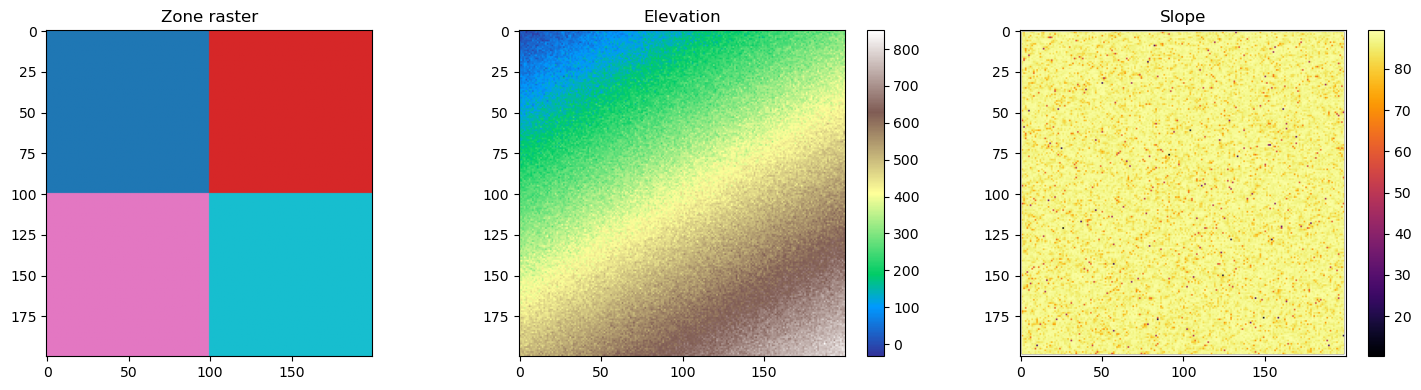

In [10]:
from xrspatial import slope
from xrspatial.zonal import stats as zonal_stats

# Zone polygons
zones_gdf = gpd.GeoDataFrame({
    'zone': [1.0, 2.0, 3.0, 4.0],
    'name': ['NW', 'NE', 'SW', 'SE'],
}, geometry=[
    box(0, 50, 50, 100),
    box(50, 50, 100, 100),
    box(0, 0, 50, 50),
    box(50, 0, 100, 50),
])

# Synthetic elevation on a 200x200 grid
rng = np.random.default_rng(42)
yy, xx = np.meshgrid(np.linspace(0, 1, 200), np.linspace(0, 1, 200),
                     indexing='ij')
elev_template = make_template(200, 200, (0, 0, 100, 100), dtype=np.float32)
elevation = elev_template.copy(
    data=(yy * 500 + xx * 300 + rng.normal(0, 20, (200, 200))).astype(np.float32))

# Rasterize zones onto the elevation grid via accessor
zone_raster = elevation.xrs.rasterize(
    zones_gdf, column='zone', fill=0, dtype=np.int32)

# Compute slope and zonal stats
slp = slope(elevation)
stats_df = zonal_stats(zone_raster, elevation)
print("Zonal statistics (elevation by zone):")
print(stats_df)

# Plot
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].imshow(zone_raster.values, cmap='tab10', origin='upper')
axes[0].set_title('Zone raster')
im1 = axes[1].imshow(elevation.values, cmap='terrain', origin='upper')
axes[1].set_title('Elevation')
plt.colorbar(im1, ax=axes[1])
im2 = axes[2].imshow(slp.values, cmap='inferno', origin='upper')
axes[2].set_title('Slope')
plt.colorbar(im2, ax=axes[2])
plt.tight_layout()
plt.show()

## 9. Using `all_touched`

By default, only pixels whose center falls inside the polygon are burned.  With `all_touched=True`, any pixel touched by the polygon boundary is included.  This matters most for thin or small features.

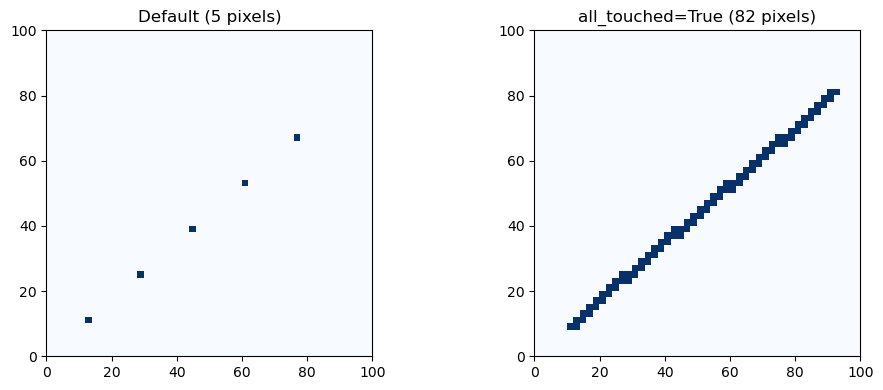

In [11]:
# Thin diagonal strip -- easily missed by center-sampling
thin_strip = Polygon([(10, 10), (90, 80), (92, 82), (12, 12), (10, 10)])

small_50 = make_template(50, 50, (0, 0, 100, 100))
normal = small_50.xrs.rasterize([(thin_strip, 1.0)], fill=0, all_touched=False)
touched = small_50.xrs.rasterize([(thin_strip, 1.0)], fill=0, all_touched=True)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(normal.values, cmap='Blues', origin='upper',
               extent=[0, 100, 0, 100])
axes[0].set_title(f'Default ({int(np.sum(normal.values == 1))} pixels)')
axes[1].imshow(touched.values, cmap='Blues', origin='upper',
               extent=[0, 100, 0, 100])
axes[1].set_title(f'all_touched=True ({int(np.sum(touched.values == 1))} pixels)')
plt.tight_layout()
plt.show()

## 10. List-of-pairs input (standalone function)

You can skip GeoDataFrame entirely and pass `(geometry, value)` pairs directly. This works with both the accessor and the standalone `rasterize()` function.

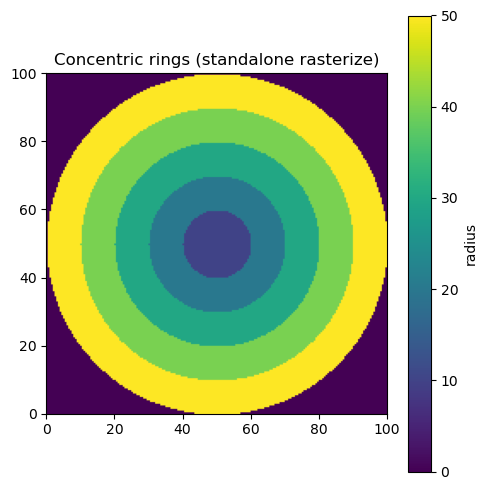

In [12]:
# Concentric rings using list-of-pairs
pairs = []
for radius in [50, 40, 30, 20, 10]:
    circle = Point(50, 50).buffer(radius)
    pairs.append((circle, float(radius)))

# Standalone function -- useful when no template raster exists yet
rings = rasterize(pairs, width=200, height=200,
                  bounds=(0, 0, 100, 100), fill=0)

fig, ax = plt.subplots(figsize=(5, 5))
im = ax.imshow(rings.values, cmap='viridis', origin='upper',
               extent=[0, 100, 0, 100])
ax.set_title('Concentric rings (standalone rasterize)')
plt.colorbar(im, ax=ax, label='radius')
plt.tight_layout()
plt.show()